# СКАЧИВАНИЕ БИБЛИОТЕК

In [10]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.2 MB/s eta 0:00:00


# 0. ПОДГРУЖАЕМ БИБЛИОТЕКИ

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
from xgboost import XGBClassifier


# 1. ЗАГРУЗКА

In [22]:
df = pd.read_csv('dataset_FINISH.csv')

# 2. МОЩНАЯ ВЕКТОРИЗАЦИЯ

In [23]:
# Мы объединяем анализ СЛОВ (1-2 слова) и анализ СИМВОЛОВ (3-5 букв).
# Это поймает "ВЫИГРАЛИ", "В.Ы.И.Г.Р.А.Л.И" и "Vыиграли" одновременно.
text_transformer = TfidfVectorizer(
    analyzer='char_wb', # Анализ внутри слов (символьные n-граммы)
    ngram_range=(3, 5),
    max_features=15000,
    sublinear_tf=True
)

# 3. ПОДГОТОВКА ДАННЫХ

In [24]:
X = df.drop(['Message_ID', 'Is_Fraud'], axis=1)
y = df['Is_Fraud']

# Числовые признаки
num_cols = ['text_length', 'word_count', 'avg_word_length', 'sentence_count',
            'punctuation_count', 'digit_count', 'uppercase_ratio',
            'space_count', 'unique_word_ratio']

# Разделение на тест и трейн
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# 4. СОЗДАНИЕ ПАЙПЛАЙНА (Чтобы всё было в одном месте)

In [25]:
# Векторизируем текст и оставляем числа как есть
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, 'Text'),
        ('num', 'passthrough', num_cols)
    ]
)

# Настройка XGBoost на стероидах
model = XGBClassifier(
    n_estimators=2000,       # Больше деревьев
    max_depth=10,            # Глубокие деревья для сложных зависимостей
    learning_rate=0.02,      # Маленький шаг для идеальной точности
    subsample=0.9,           # Берем 90% данных для каждого дерева
    colsample_bytree=0.9,    # Берем 90% признаков
    gamma=0.1,               # Регуляризация (чтобы не переобучалась)
    scale_pos_weight=(len(y) - sum(y)) / sum(y), # Автоматический баланс классов фрод/не фрод
    tree_method='hist',      # Ускорение обучения
    random_state=42
)

# Собираем всё в одну цепочку
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])


# 5. ОБУЧЕНИЕ

In [26]:
print("Запуск обучения модели...")
clf.fit(X_train, y_train)

Запуск обучения модели...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(analyzer='char_wb',
                                                                  max_features=15000,
                                                                  ngram_range=(3,
                                                                               5),
                                                                  sublinear_tf=True),
                                                  'Text'),
                                                 ('num', 'passthrough',
                                                  ['text_length', 'word_count',
                                                   'avg_word_length',
                                                   'sentence_count',
                                                   'punctuation_count',
                                                   'digit_count',
                                                   'uppercase_ratio',
                                                   'space_count',
                                                   'unique_word_ratio'])])),
                ('cl...
                               feature_types=None, feature_weights=None,
                               gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.02,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=10, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=2000, n_jobs=None,
                               num_parallel_tree=None, ...))])

#  6. СОХРАНЕНИЕ

In [27]:
# Векторизатор вытаскиваем из обученного пайплайна
joblib.dump(clf.named_steps['preprocessor'], 'vectorizer.pkl')
# Модель вытаскиваем отдельно
joblib.dump(clf.named_steps['classifier'], 'fraud_model.pkl')

print("Файлы fraud_model.pkl и vectorizer.pkl созданы.")

Файлы fraud_model.pkl и vectorizer.pkl созданы.


# 7. ГРАФИКИ И МЕТРИКИ

In [28]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(18, 5))


<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

# Матрица ошибок

Text(50.722222222222214, 0.5, 'Реально')

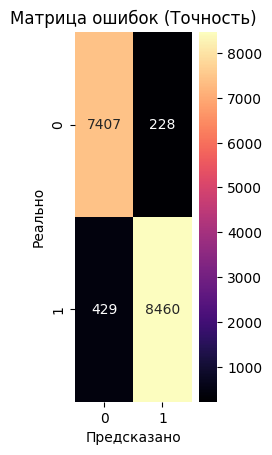

In [29]:
plt.subplot(1, 3, 1)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='magma')
plt.title('Матрица ошибок (Точность)')
plt.xlabel('Предсказано')
plt.ylabel('Реально')


# ROC-AUC

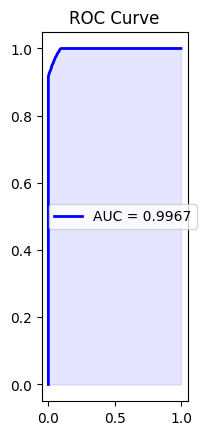

In [30]:
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc_score(y_test, y_proba):.4f}')
plt.fill_between(fpr, tpr, alpha=0.1, color='blue')
plt.title('ROC Curve')
plt.legend()


# Precision-Recall

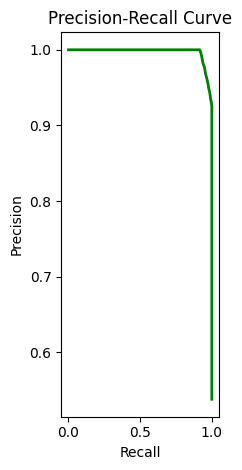

In [31]:
plt.subplot(1, 3, 3)
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, color='green', lw=2)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')

plt.tight_layout()
plt.show()

# ОБЩИЙ ОТЧЕТ

In [32]:
print("\n--- ОТЧЕТ ПО ТОЧНОСТИ ---")
print(classification_report(y_test, y_pred))


--- ОТЧЕТ ПО ТОЧНОСТИ ---
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      7635
           1       0.97      0.95      0.96      8889

    accuracy                           0.96     16524
   macro avg       0.96      0.96      0.96     16524
weighted avg       0.96      0.96      0.96     16524

